# Spin-Texture Calculation    
**by <span style="color:darkgreen">Benedikt Maurer</span> for [<span style="color:darkgoldenrod">exciting *sodium*</span>](https://www.exciting-code.org/sodium)**

<font size="2">(Jupyter notebook by <span style="color:darkgreen">Mara Voiculescu</span> & <span style="color:darkgreen">Martin Kuban</span>)</font>
<hr style="border:2px solid #DDD"> </hr>

**<span style="color:firebrick">Purpose</span>**: In this tutorial you will learn how to calculate the **spin texture** with **`exciting`** for **GaAs**.
<hr style="border:2px solid #DDD"> </hr>

<div class="alert alert-block alert-warning">

**Table of Contents**
    
[0. Before Starting](#0)
    
[1. Theoretical Background](#1)  
      
[2. Spin Texture of GaAs](#2)
    
[Literature](#3)

</div>

<a id='0'></a>
<hr style="border:1px solid #DDD"> </hr>

### <span style="color:#15317E">0. Before Starting</span>

**<span style="color:firebrick">Read the following paragraphs before starting with the rest of this tutorial!</span>**

Before running any Jupyter tutorials, please refer to the **`00_before_starting.md`** document on how to correctly set up the environment. This only needs to be done once. After which, the **venv** can be (re)activated from **`exciting`**'s root directory:

<div style="background-color: rgb(224, 224, 224);">

```bash
source $EXCITINGROOT/tools/excitingjupyter/venv/excitingvenv/bin/activate
```

</div>

As a first step, you may create a running directory for the notebook.

In [1]:
%%bash
mkdir -p run_tutorial_spin_texture

<a id='1'></a>
<hr style="border:1px solid #DDD"> </hr>

### <span style="color:#15317E">1. Theoretical Background</span>

An interesting property of the electronic structure with spin-orbit coupling (**SOC**) is the so-called **spin texture**. It can be used, *e.g.*, to differentiate between the Rashba and the Dresselhaus effect (see **[<span style="color:firebrick">Kepenekian2015</span>](#3)**).

The spin texture $\boldsymbol s(n,\boldsymbol k)$ is defined as the expectation value of a vector of Pauli matrices on a two dimensional **k**-grid. At **k** for the state n it is defined as:

\begin{equation}
\tag{1}
\boldsymbol s(n,\boldsymbol k) = \langle n,\boldsymbol k|\boldsymbol \sigma | n,\boldsymbol k \rangle
\end{equation}

<a id='2'></a>
<hr style="border:1px solid #DDD"> </hr>

### <span style="color:#15317E">2. Spin Texture of GaAs</span>

To calculate the **spin texture** for **GaAs**, create the file **input.xml** and save the following lines into it: 

<span class="SPIN_TEXTURE"></span>
```xml
<input>
   <title>GaAs spin texture</title>
 
   <structure speciespath="$EXCITINGROOT/species">
      <crystal scale="10.683" >
         <basevect>  0.0     0.5     0.5 </basevect>
         <basevect>  0.5     0.0     0.5 </basevect>
         <basevect>  0.5     0.5     0.0 </basevect>
      </crystal>
 
      <species speciesfile='Ga.xml' rmt='2.0'>
         <atom coord="0.00 0.00 0.00"/>
      </species>
 
      <species speciesfile='As.xml' rmt='2.0'>
         <atom coord="0.25 0.25 0.25"/>
      </species>
   </structure>
 
   <groundstate
      do="fromscratch"
      xctype="GGA_PBE"
      rgkmax="6"
      gmaxvr="15"
      ngridk="4 4 4"
      swidth="1d-6"
      epsengy="1d-6"
      maxscl="40"
      nempty="15">
 
      <spin spinorb="true"/>
   </groundstate>
 
   <properties>
      <spintext bands="23 30">
         <plot2d>
            <parallelogram grid = "12 12">
               <origin coord = "-0.042506  -0.042506  -0.085013"/>
               <point  coord = "-0.042506   0.050235   0.007728"/>
               <point  coord = " 0.050235  -0.042506   0.007728"/>
            </parallelogram>
         </plot2d>
      </spintext>
   </properties>
</input>

```

In [2]:
from excitingjupyter.utilities import get_input_xml_from_notebook   

# Extract input file content from this notebook:
input_str = get_input_xml_from_notebook("spin_texture_calculation", "SPIN_TEXTURE")

# Write out the input as an XML file:
with open('./run_tutorial_spin_texture/input.xml', "w") as fid:
    fid.write(input_str)

Then, set up the correct species path and run **`exciting`** to perform the groundstate calculation:

In [3]:
%%bash
cd run_tutorial_spin_texture
python3 -m excitingscripts.setup.excitingroot
time $EXCITINGROOT/install/bin/exciting_smp input.xml
cd ..

 ### Using specified input file: input.xml
 ### Using specified input file: input.xml


   Elapsed time = 1m19s


Note that **spin-orbit coupling** (**SOC**) is enabled <code><span style="color:mediumblue">spinorb</span>=<span style="color:firebrick">"true"</span></code>. **Spin texture** calculations are only allowed for ground states with enabled **SOC**.

Note also the <code><span style="color:green">spintext</span></code> element in the <code><span style="color:green">properties</span></code> element:
- The <code><span style="color:mediumblue">bands</span></code> attribute defines the band range that is considered. In this case we are interested in the bands around the band gap. You can extract the band numbers from the **EIGVAL.OUT**.
- The <code><span style="color:green">parallelogram</span></code> element defines the **k**-grid for the spin texture calculation. The **k**-points are homogeneously distributed on a parallelogram in the reciprocal space. In the example of this tutorial, we consider a square with sidelength 0.1 [a.u.] (a.u. = Bohr-1) in the (k<sub>x</sub>, k<sub>y</sub>) plane. The centre of this square is the Γ point and the borders are parallel to the Cartesian k<sub>x</sub> and k<sub>y</sub> axes.
- <code><span style="color:mediumblue">grid</span></code> defines the number of **k**-points per direction.
- The parallelogram is spanned between <code><span style="color:green">origin</span></code> and the points defined by <code><span style="color:green">point</span></code>.

Be aware of that <code><span style="color:mediumblue">coord</span></code> is given in reciprocal coordinates.

When the calculation is done, you can plot the spin texture for the first conduction band using the script **`excitingscripts.plot.spintext`** (for a detailed description of the script arguments see **[The python script "plot.spintext"](https://www.exciting-code.org/home/the-python-script-plot.spintext)**) as follows:

In [86]:
%%bash
cd run_tutorial_spin_texture
python3 -m excitingscripts.plot.spintext -b 29 -c energy 
cd ..

- <code><span style="color:mediumblue">-b</span></code> defines the band that is considered for the plot which is in this case the first conduction band. You can extract the numbers of the states from **EIGVAL.OUT**.
- <code><span style="color:mediumblue">-c</span></code> specifies if the energy or the z component of the spin orientation is considered for the contour plot. The choices are **"energy"** or **"spin_z"**.

Note that the script is designed for rectangular spin textures!

The resulting **PNG** file **PLOT-spintext.png** can be should look like the following:

<figure>
<img src=" 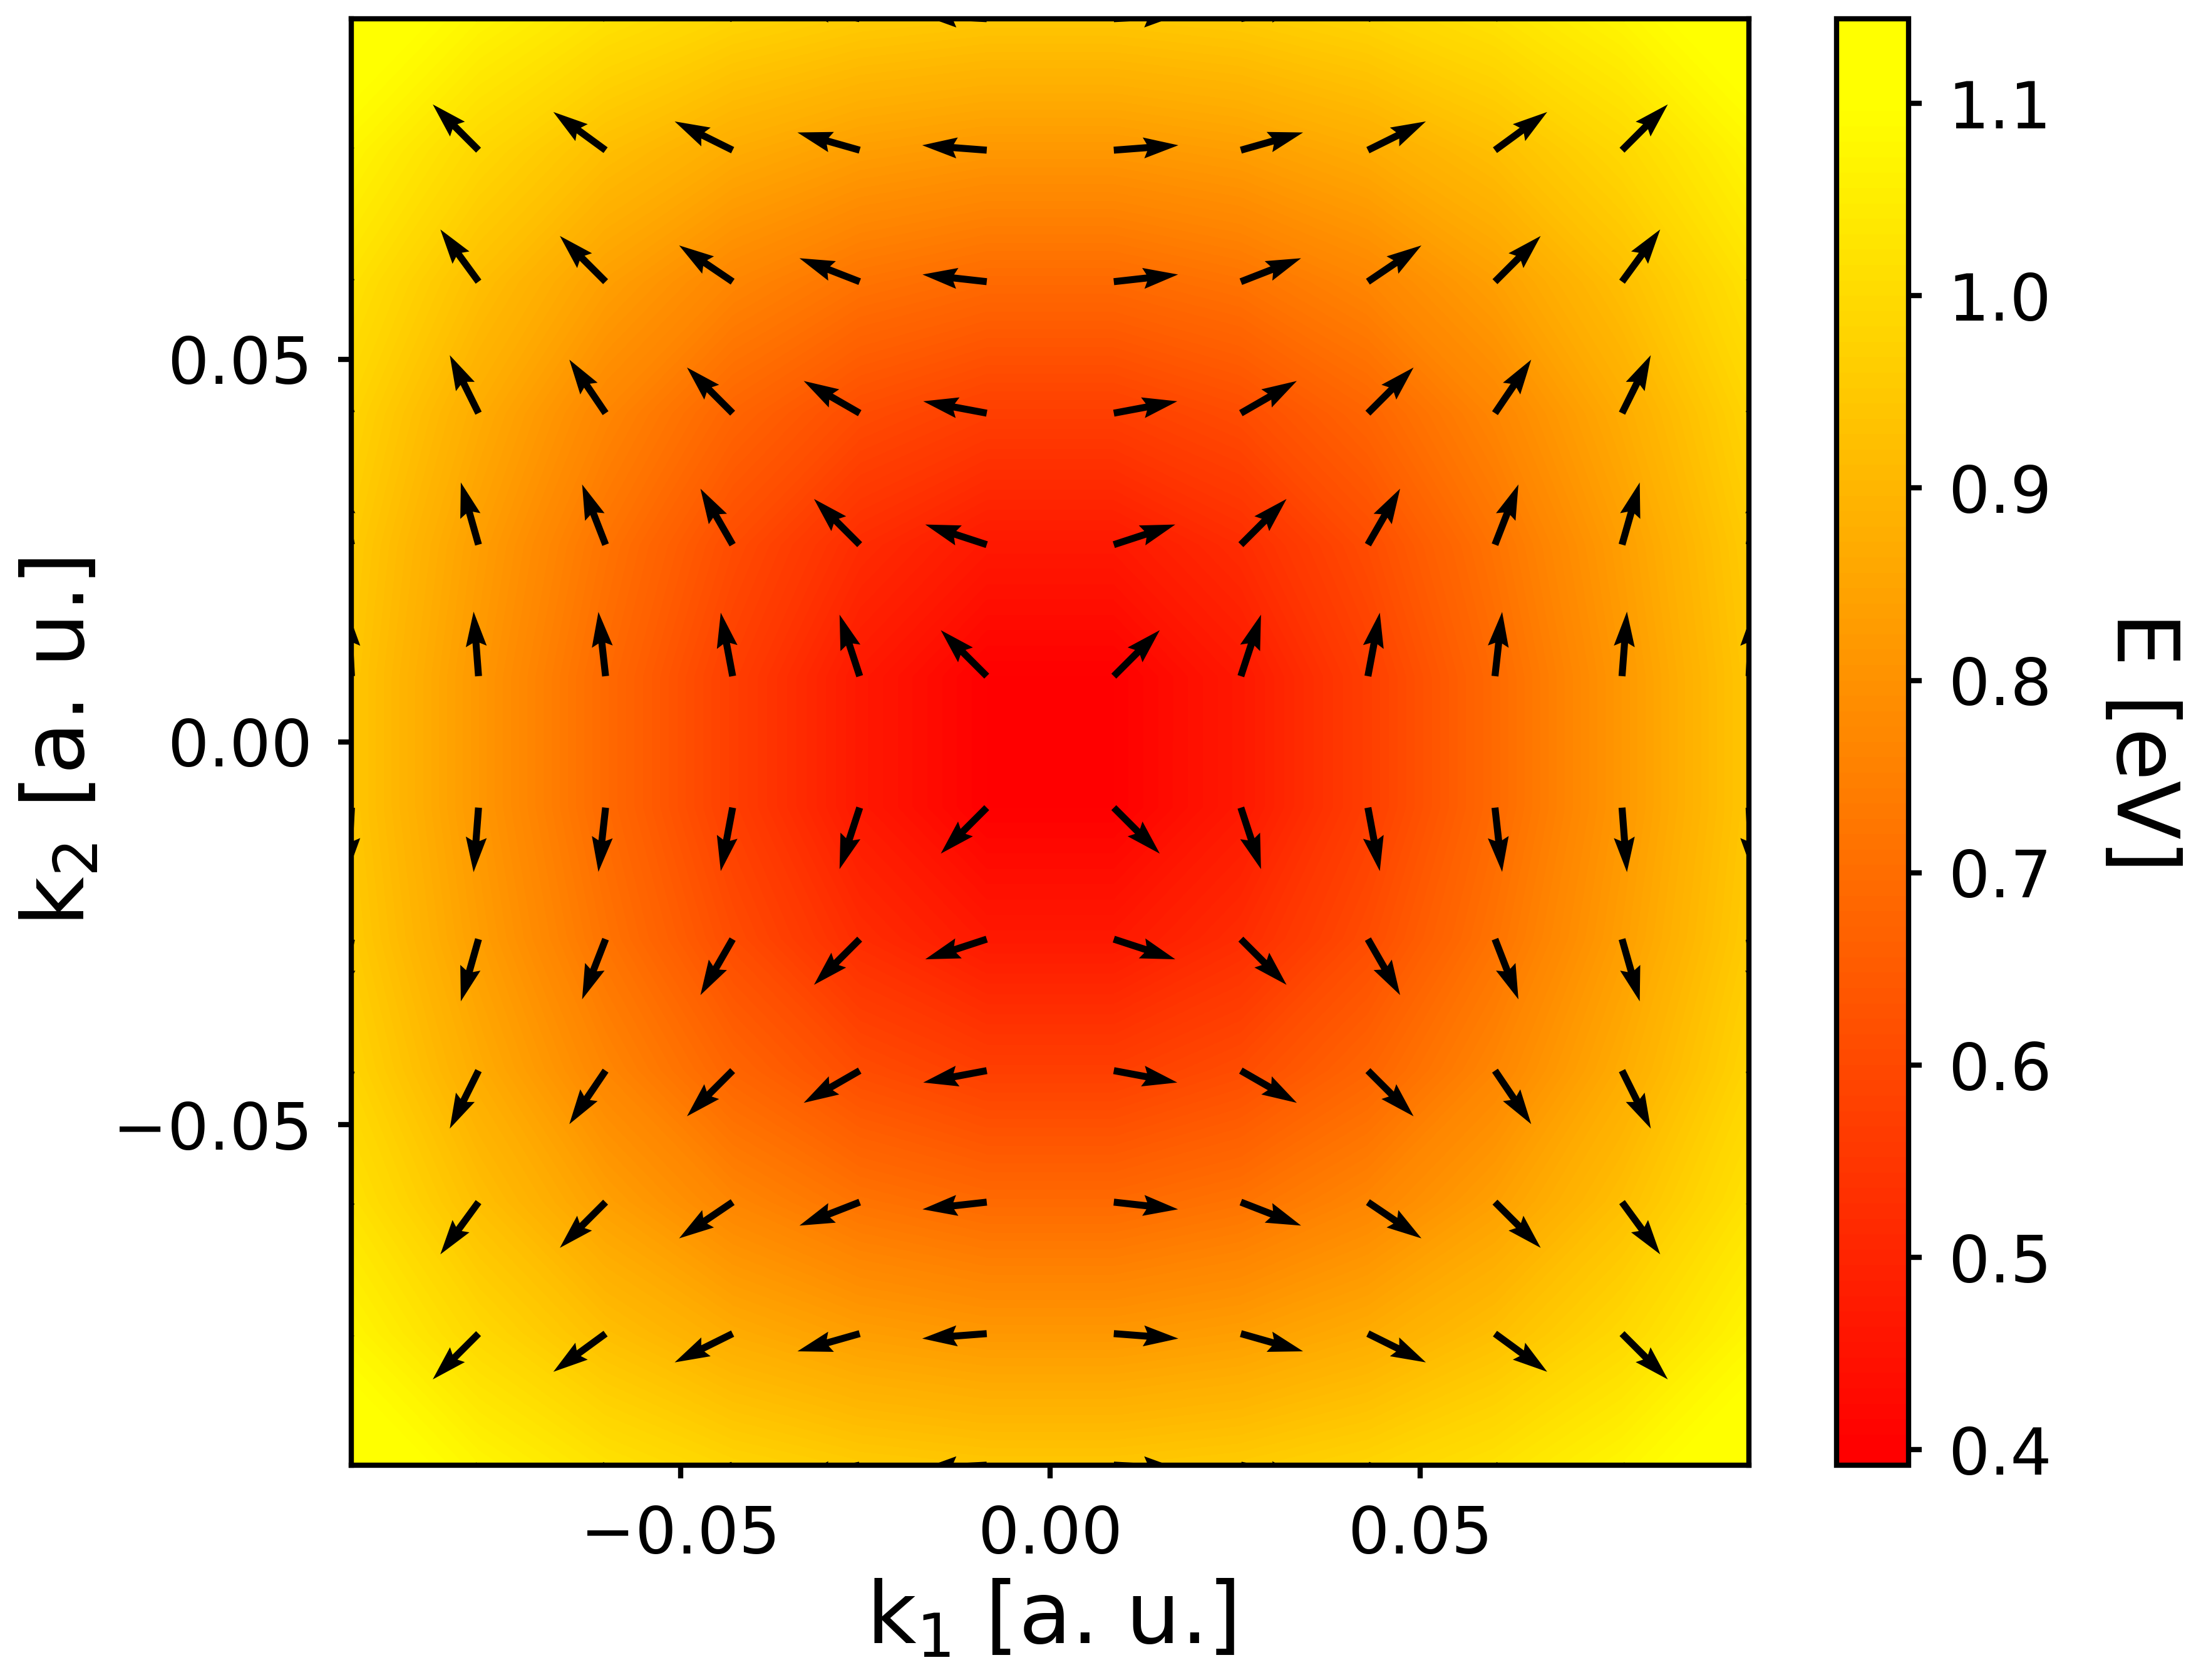" width="600" align="left"/>
</figure>

In the plot, k<sub>1</sub> and k<sub>2</sub> correspond to the **k**-vectors (k<sub>1</sub>,0,0)<sup>T</sup> and (0,k<sub>2</sub>,0)<sup>T</sup>, respectively. The color map represents the energy of the chosen state. Note that the unit of k<sub>1</sub> and k<sub>2</sub> are given in atomic units (Bohr<sup>-1</sup>).

<a id='3'></a>
<hr style="border:1px solid #DDD"> </hr>

### <span style="color:#15317E">Literature</span>

- **<span style="color:firebrick">Kepenekian2015</span>**: The form of the spin texture and more information on Rashba and Dresselhaus effects is given in: M. Kepenekian, R. Robles, C. Katan, D. Sapori, L. Pedesseau, & J. Even. *Rashba and Dresselhaus Effects in Hybrid Organic-Inorganic Perovskites: From Basics to Devices*. ACS Nano, 9(12), 11557–11567 (2015). **[DOI](https://doi.org/10.1021/acsnano.5b04409)**


<hr style="border:2px solid #DDD"> </hr>